## Cleaning and Reshaping

In [23]:
# 1. Load Libraries
library(tidyverse)
library(scales)

# 2. Setup Path Configuration
# Navigating from notebooks/r -> notebooks -> root -> data -> cleaned
data_dir <- "../../data/cleaned/"
er_file <- paste0(data_dir, "exchange_rate.csv")
exports_file <- paste0(data_dir, "value_domestic_exports.csv")

# 3. Load & Clean Exchange Rate Data
df_er <- read.csv(er_file, skip = 1, stringsAsFactors = FALSE) %>%
  dplyr::rename(
    year = Year, 
    month_num = Month, 
    usd_rate = United.States.dollar
  ) %>%
  dplyr::filter(!is.na(year) & grepl("^[0-9]+$", year)) %>%
  dplyr::mutate(
    year = as.numeric(year),
    month_num = as.numeric(month_num),
    usd_rate = as.numeric(usd_rate)
  ) %>%
  dplyr::select(year, month_num, usd_rate)

# 4. Load & Clean Domestic Exports Data
month_lookup <- setNames(1:12, month.name)

df_exports <- read.csv(exports_file, stringsAsFactors = FALSE) %>%
  dplyr::mutate(month_num = month_lookup[month])

# 5. Merge and Calculate Real Value
# Using explicit dplyr::inner_join to solve the "function not found" error
df_final <- dplyr::inner_join(df_exports, df_er, by = c("year", "month_num")) %>%
  dplyr::mutate(
    date = as.Date(paste(year, month_num, "01", sep = "-"), format = "%Y-%m-%d"),
    total_usd = total / usd_rate
  ) %>%
  dplyr::arrange(date)

# Final check of the merged data
print("Merge Successful. Preview:")
head(df_final)



[1] "Merge Successful. Preview:"


,year,month,coffee,tea,petroleum,chemicals,fish,horticulture,cement,other,total,month_num,usd_rate,date,total_usd
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>,<dbl>
1,1998,August,500.47,2404.70,850.60,695.15,183.19,854.04,117.68,3543.33,9149.16,8,59.37,1998-08-01,154.1041
2,1998,September,536.21,2564.06,848.42,606.82,204.02,1446.75,99.66,3555.47,9861.40,9,60.01,1998-09-01,164.3293
3,1998,October,584.32,2450.01,896.47,587.63,306.09,1659.82,136.22,2690.39,9310.95,10,59.87,1998-10-01,155.5195
4,1998,November,578.74,2295.48,784.25,890.20,235.66,1295.53,96.46,2457.39,8633.71,11,59.63,1998-11-01,144.7880
5,1998,December,574.54,2129.77,799.11,724.44,81.92,1491.47,111.75,3166.33,9079.32,12,61.82,1998-12-01,146.8670
6,1999,January,224.79,2393.41,889.15,493.20,258.26,1346.01,90.15,2760.98,8455.96,1,61.80,1999-01-01,136.8278


## 1.Nominal (KES) vs. Real (USD)

In [ ]:
# Visualization: Nominal (KES) vs. Real (USD)
ggplot(df_final, aes(x = date)) +
  geom_line(aes(y = total, color = "Nominal Value (KES Millions)"), linewidth = 1) +
  geom_line(aes(y = total_usd * 100, color = "Real Value (USD Millions x 100)"), 
            linewidth = 1, alpha = 0.7, linetype = "dashed") +
  scale_y_continuous(labels = scales::label_comma()) +
  scale_color_manual(values = c(
    "Nominal Value (KES Millions)" = "#2c3e50", 
    "Real Value (USD Millions x 100)" = "#e74c3c"
  )) +
  labs(
    title = "Kenya Exports: Nominal vs. Real Growth",
    subtitle = "Gap post-2022 highlights the impact of currency devaluation",
    x = "Year", 
    y = "Value (Scaled)",
    color = "Metric",
    caption = "Source: Central Bank of Kenya | USD value scaled by 100 for trend comparison"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")


## 2. Kenyan Shilling performance against the world's three major reserve currencies.

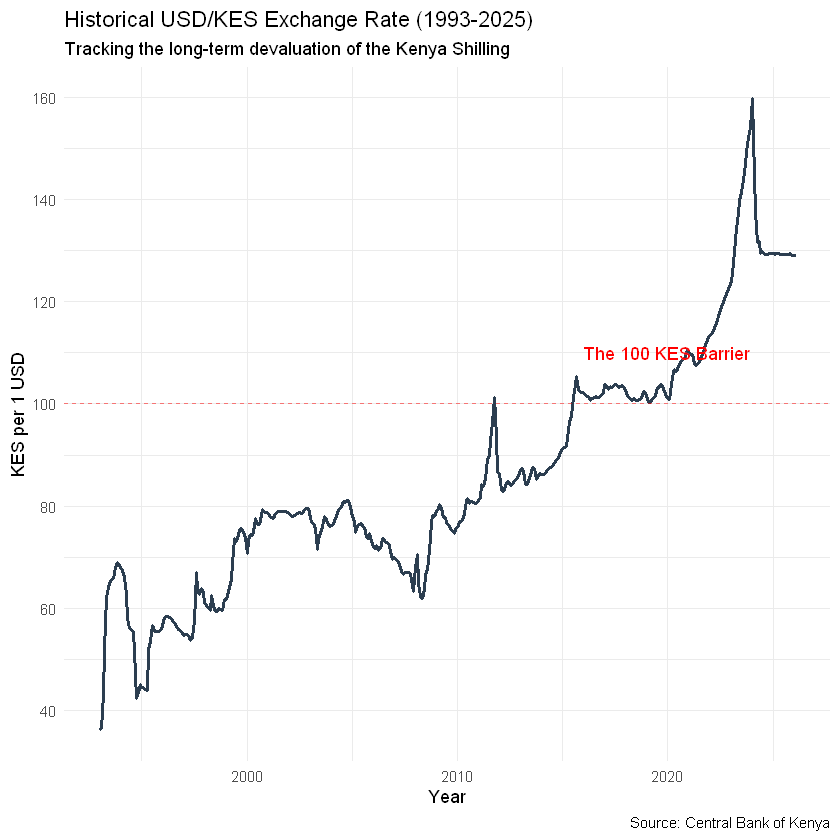

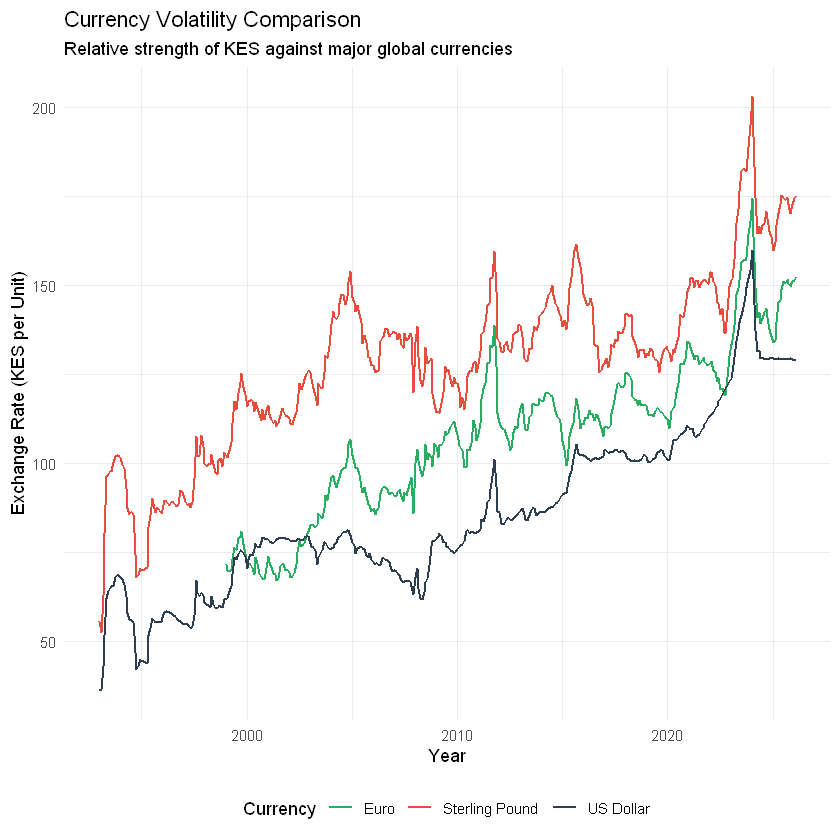

In [24]:
library(tidyverse)
library(scales)

# 1. Path Configuration
data_dir <- "../../data/cleaned/"
er_file <- paste0(data_dir, "exchange_rate.csv")

# 2. Load and Clean
# Skipping row 1 because CBK files have a title on the first line
df_er_clean <- read.csv(er_file, skip = 1, stringsAsFactors = FALSE) %>%
  dplyr::rename(
    year = Year, 
    month_num = Month, 
    usd = United.States.dollar,
    gbp = Sterling.pound,
    euro = Euro
  ) %>%
  # Filter out non-numeric header/footer rows
  dplyr::filter(!is.na(year) & grepl("^[0-9]+$", year)) %>%
  dplyr::mutate(across(c(year, month_num, usd, gbp, euro), as.numeric)) %>%
  # Create a proper date
  dplyr::mutate(date = as.Date(paste(year, month_num, "01", sep = "-"), format = "%Y-%m-%d")) %>%
  dplyr::arrange(date)

# 3. Visualization A: The USD Benchmark (The "Shilling's Journey")
ggplot(df_er_clean, aes(x = date, y = usd)) +
  geom_line(color = "#2c3e50", linewidth = 1) +
  geom_hline(yintercept = 100, linetype = "dashed", color = "red", alpha = 0.5) +
  annotate("text", x = as.Date("2020-01-01"), y = 110, label = "The 100 KES Barrier", color = "red") +
  scale_y_continuous(breaks = seq(0, 180, 20)) +
  labs(
    title = "Historical USD/KES Exchange Rate (1993-2025)",
    subtitle = "Tracking the long-term devaluation of the Kenya Shilling",
    x = "Year", y = "KES per 1 USD",
    caption = "Source: Central Bank of Kenya"
  ) +
  theme_minimal()

# 4. Visualization B: Global Comparison (USD vs GBP vs EUR)
# We pivot the data to make it 'long' for ggplot
df_er_long <- df_er_clean %>%
  dplyr::select(date, usd, gbp, euro) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Currency", values_to = "Rate") %>%
  dplyr::filter(!is.na(Rate)) # Remove years before the Euro existed

ggplot(df_er_long, aes(x = date, y = Rate, color = Currency)) +
  geom_line(linewidth = 0.8) +
  scale_color_manual(
    values = c("usd" = "#2c3e50", "gbp" = "#e74c3c", "euro" = "#27ae60"),
    labels = c("euro" = "Euro", "gbp" = "Sterling Pound", "usd" = "US Dollar")
  ) +
  labs(
    title = "Currency Volatility Comparison",
    subtitle = "Relative strength of KES against major global currencies",
    x = "Year", y = "Exchange Rate (KES per Unit)",
    color = "Currency"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")